### Ratio di questo notebook

Sto utilizzando questo notebook come posto _tutto-in-uno_ per esplorare i dati, fare osservazioni e prototipare tutti i modelli e i codici del progetto. A seguito di un refactoring, per evitare di avere codice duplicato, ho spostato in larga parte il codice nella cartella /src eliminandolo dal notebook (per esempio tutti i codici di verifica dell'ambiente e di download del dataset). Le parti di codice più interessanti sono comunque state mantenute anche nel notebook per garantire una maggiore leggibilità e scorrevolezza.

In [1]:
# Aggiungiamo la cartella root al sys path 
# (necessario per accedere alle nostre implementazioni nella sotto cartella /src)
import sys
import os

# Calcola il percorso assoluto della cartella superiore (root del progetto)
project_root = os.path.abspath("..")

# La aggiunge solo se non è già presente (evita duplicati se riesegui la cella)
if project_root not in sys.path:
    sys.path.append(project_root)


#### Verifica dell'Ambiente PyTorch e della GPU


In [2]:
from src import utils

utils.verify_torch_gpu()

=== Verifica Setup PyTorch e GPU ===
Versione PyTorch: 2.13.0+cu126
CUDA Disponibile: True
Versione CUDA integrata: 12.6
Numero di GPU rilevate: 1
Nome GPU: NVIDIA GeForce GTX 1050 Ti
Capacità Computazionale: (6, 1)
Test allocazione tensore su GPU: RIUSCITO (Dispositivo: cuda:0)


#### Download del dataset ed estrazione

#### Analisi della struttura del Dataset GTSRB (German Traffic Sign Recognition Benchmark)

Il dataset GTSRB è un benchmark classico per la classificazione di cartelli stradali tedeschi tramite visione artificiale.

##### Organizzazione delle Cartelle (`../data/`)
- **`Train/`**: Contiene 43 sottocartelle numerate da `0` a `42`. Ogni cartella racchiude le immagini `.png` corrispondenti a una specifica classe di segnale stradale.
- **`Test/`**: Contiene l'insieme delle immagini di test prive di suddivisione in sottocartelle (la classe reale è specificata nel file `Test.csv`).
- **`Meta/`**: Contiene le immagini di esempio ad alta risoluzione/grafica vettoriale rappresentative di ciascuna delle 43 classi.
- **`Train.csv`**: File di annotazione principale per l'addestramento (39.209 righe).
- **`Test.csv`**: File di annotazione per la valutazione del modello (12.630 righe).
- **`Meta.csv`**: File di metadati sulle classi.

##### Struttura dei File `Train.csv` e `Test.csv`
Ogni file CSV contiene 8 colonne fondamentali:
1. **`Width`**: Larghezza originale dell'immagine (in pixel).
2. **`Height`**: Altezza originale dell'immagine (in pixel).
3. **`Roi.X1`**: Coordinata X in alto a sinistra del rettangolo che ritaglia il segnale stradale (Region of Interest).
4. **`Roi.Y1`**: Coordinata Y in alto a sinistra della ROI.
5. **`Roi.X2`**: Coordinata X in basso a destra della ROI.
6. **`Roi.Y2`**: Coordinata Y in basso a destra della ROI.
7. **`ClassId`**: ID numerico intero della classe (da `0` a `42`, per un totale di 43 classi).
8. **`Path`**: Percorso relativo al file immagine `.png` all'interno della cartella `data/`.

##### Struttura del File `Meta.csv`
Il file `Meta.csv` associa a ciascuna delle 43 classi alcune informazioni geometriche e categoriche utili per la classificazione e la visualizzazione:
1. **`Path`**: Percorso dell'immagine di esempio rappresentativa della classe (es. `Meta/0.png`).
2. **`ClassId`**: ID numerico unico della classe (da 0 a 42).
3. **`ShapeId`**: Codice identificativo della forma geometrica del cartello (es. triangolare, circolare, ottagonale, quadrato).
4. **`ColorId`**: Codice identificativo della combinazione di colori principale del segnale (es. bordo rosso, sfondo blu, sfondo giallo/bianco).
5. **`SignId`**: Codice di riferimento ufficiale del catalogo del codice della strada tedesco (StVO - Straßenverkehrs-Ordnung).


#### Carichiamo il dataset su pandas per una prima analisi

In [3]:
DATA_FOLDER= "../data/"
import pandas as pd
import os
K=43
df_meta= pd.read_csv(os.path.join(DATA_FOLDER, "Meta.csv"))
df_train= pd.read_csv (os.path.join(DATA_FOLDER, "Train.csv"))
df_test= pd.read_csv (os.path.join(DATA_FOLDER, "Test.csv"))

In [4]:
asample= df_train.sample(1).merge(right=df_meta, suffixes=("","_meta"), on="ClassId")
asample.iloc[0]


Width                                    37
Height                                   37
Roi.X1                                    6
Roi.Y1                                    6
Roi.X2                                   32
Roi.Y2                                   32
ClassId                                  12
Path         Train/12/00012_00038_00006.png
Path_meta                       Meta/12.png
ShapeId                                   2
ColorId                                   2
SignId                                  2.3
Name: 0, dtype: object

#### Visualizziamo un sample random dal dataset

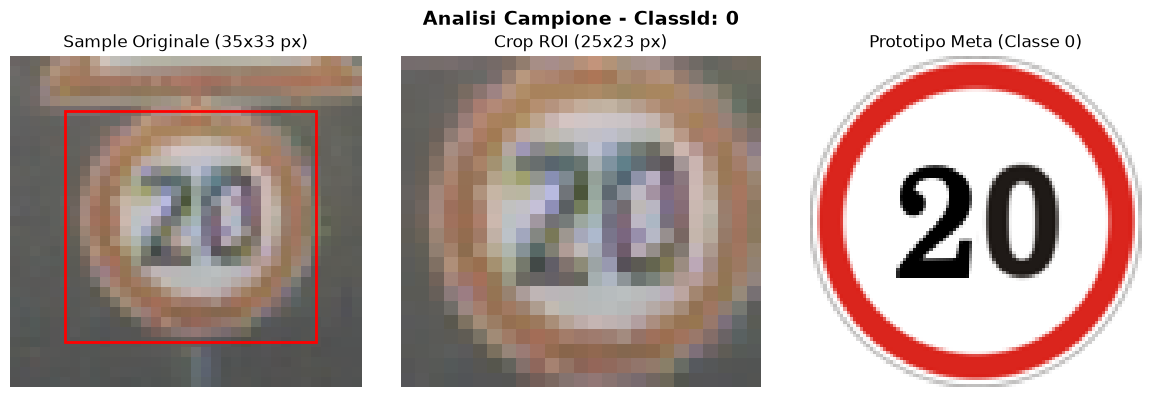

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image


asample = df_train.sample(1).merge(df_meta, on="ClassId", suffixes=("", "_meta"))
sample = asample.iloc[0]

# 2. Caricamento delle immagini
img_train_path = os.path.join(DATA_FOLDER, sample["Path"])
img_meta_path = os.path.join(DATA_FOLDER, sample["Path_meta"])

img_train = Image.open(img_train_path)
img_meta = Image.open(img_meta_path)

# Ritaglio della ROI (left, upper, right, lower)
roi_crop = img_train.crop((sample["Roi.X1"], sample["Roi.Y1"], sample["Roi.X2"], sample["Roi.Y2"]))

# 3. Creazione della figura Matplotlib a 3 pannelli
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# --- Pannello 1: Immagine originale + Bounding Box ROI ---
axes[0].imshow(img_train)
axes[0].set_title(f"Sample Originale ({sample['Width']}x{sample['Height']} px)")
rect = patches.Rectangle(
    (sample["Roi.X1"], sample["Roi.Y1"]),
    sample["Roi.X2"] - sample["Roi.X1"],
    sample["Roi.Y2"] - sample["Roi.Y1"],
    linewidth=2, edgecolor='red', facecolor='none'
)
axes[0].add_patch(rect)
axes[0].axis('off')

# --- Pannello 2: Crop della ROI ---
axes[1].imshow(roi_crop)
axes[1].set_title(f"Crop ROI ({roi_crop.width}x{roi_crop.height} px)")
axes[1].axis('off')

# --- Pannello 3: Prototipo Canonico da Meta ---
axes[2].imshow(img_meta)
axes[2].set_title(f"Prototipo Meta (Classe {sample['ClassId']})")
axes[2].axis('off')

plt.suptitle(f"Analisi Campione - ClassId: {sample['ClassId']}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()




#### Verifichiamo la distribuzione delle classi

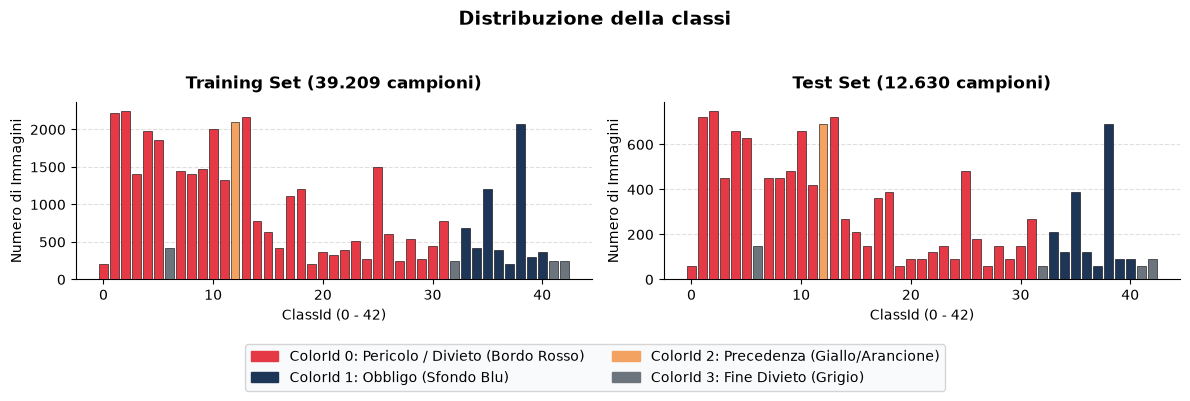

In [6]:
import matplotlib.patches as mpatches
# 1. Ordiniamo df_meta per ClassId (da 0 a 42) per abbinare l'ordine delle barre
meta_sorted = df_meta.sort_values("ClassId")
# 2. Definiamo la tavolozza dei colori in esadecimale (HEX)
color_map = {
    0: '#e63946',  # Rosso (Pericolo / Divieti)
    1: '#1d3557',  # Blu (Obbligo / Indicazione)
    2: '#f4a261',  # Giallo / Arancione (Precedenza)
    3: '#6c757d'   # Grigio (Fine dei divieti)
}
# 3. Creiamo la lista dei colori ordinata per ciascuna classe (0..42)
bar_colors = meta_sorted["ColorId"].map(color_map).tolist()


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

freq_train=df_train["ClassId"]
freq_train=freq_train.value_counts().sort_index()


freq_test=df_test["ClassId"]
freq_test=freq_test.value_counts().sort_index()


axes[0].bar(x=freq_train.index, height=freq_train.values, color=bar_colors, edgecolor="black", linewidth=0.4, zorder=3)
axes[0].set_title("Training Set (39.209 campioni)", fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel("ClassId (0 - 42)", fontsize=10)
axes[0].set_ylabel("Numero di Immagini", fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.4, zorder=0)  # Griglia orizzontale di sfondo
axes[0].spines['top'].set_visible(False)                     # Rimuove il bordo in alto
axes[0].spines['right'].set_visible(False)                   # Rimuove il bordo a destra
axes[1].bar(x=freq_test.index, height=freq_test.values, color=bar_colors, edgecolor="black", linewidth=0.4, zorder=3)
axes[1].set_title("Test Set (12.630 campioni)", fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel("ClassId (0 - 42)", fontsize=10)
axes[1].set_ylabel("Numero di Immagini", fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.4, zorder=0)  # Griglia orizzontale di sfondo
axes[1].spines['top'].set_visible(False)                     # Rimuove il bordo in alto
axes[1].spines['right'].set_visible(False)                   # Rimuove il bordo a destra

plt.suptitle("Distribuzione della classi", fontsize=14, fontweight='bold')
legend_patches = [
    mpatches.Patch(color='#e63946', label='ColorId 0: Pericolo / Divieto (Bordo Rosso)'),
    mpatches.Patch(color='#1d3557', label='ColorId 1: Obbligo (Sfondo Blu)'),
    mpatches.Patch(color='#f4a261', label='ColorId 2: Precedenza (Giallo/Arancione)'),
    mpatches.Patch(color='#6c757d', label='ColorId 3: Fine Divieto (Grigio)')
]
fig.legend(
    handles=legend_patches,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.01),
    ncol=2,
    fontsize=10,
    frameon=True,
    facecolor='#f8f9fa',
    edgecolor='#cccccc'
)



plt.tight_layout(rect=[0, 0.16, 1, 0.94])
plt.show()


#### Osservazione 1: il dataset è sbilanciato
Come possiamo osservare dal grafico a barre il dataset è parecchio sbilanciato, non solo tra le singole classi ma anche tra classi di colore (vi sono molti più segnali di pericolo). In seguito si calcola qualche metrica per quantificare tale sbilanciamento.
L'Entropia Normalizzata ($H$) ci fornisce un valore tra 0 e 1 che ci indica quanto la distribuzione si avvicina alla distribuzione uniforme. Calcolandone il suo complementare $D = 1 - H$ , si ottiene il Degree of Imbalance ($D$). Più D si avvicina a 1 più la distribuzione è sbilanciata nel suo complesso.
Un altra metrica molto utilizzata è l'Imbalance Ratio ($IR$), ottenuto dividendo il numero di volte in cui compare la classe maggioritaria per il numero di volte in cui compare la classe meno rappresentata.

In [7]:
import numpy as np
from IPython.display import display, Markdown


def imbalance_stats(freq_df: pd.DataFrame):
    ir=freq_df.values.max()/freq_df.values.min()
    
    sum_of_classes= freq_df.values.sum()
    dsum=0
    for i,e in enumerate(freq_df):
        p_i= e/sum_of_classes
        dsum+=(p_i)*np.log2(p_i)
    cv=0
    H= -1*dsum
    H_max = np.log2 (K)
    H_norm = H/H_max
    D= 1-H_norm

    df_summary = pd.DataFrame({
        "Metrica": ["Imbalance Ratio (IR)", "Entropia Normalizzata (H)", "Degree of Imbalance (D)"],
        "Valore Calcolato": [f"{ir:.2f}", f"{H_norm:.4f}", f"{D:.4f}"],
        "Riferimento (Bilanciato)": ["1.00", "1.00", "0.00"]
    })
    # Stampa la tabella HTML formattata
    display(df_summary)

display(Markdown("####  Metriche per: **Training Set**"))
imbalance_stats(df_train["ClassId"].value_counts().sort_index())
display(Markdown("####  Metriche per: **Test Set**"))
imbalance_stats(df_test["ClassId"].value_counts().sort_index())



####  Metriche per: **Training Set**

,Metrica,Valore Calcolato,Riferimento (Bilanciato)
0,Imbalance Ratio (IR),10.71,1.00
1,Entropia Normalizzata (H),0.9267,1.00
2,Degree of Imbalance (D),0.0733,0.00


####  Metriche per: **Test Set**

,Metrica,Valore Calcolato,Riferimento (Bilanciato)
0,Imbalance Ratio (IR),12.50,1.00
1,Entropia Normalizzata (H),0.9201,1.00
2,Degree of Imbalance (D),0.0799,0.00


#### Osservazione 2: Il training set e il test set sono distribuiti alla stessa maniera
Per confermare quanto già osservato nel grafico a barre (cioè che il training set e il test set sono distribuiti alla stessa maniera) ho calcolato la divergenza di Jensen-Shannon tra i due set.

In [8]:

from scipy.spatial.distance import jensenshannon

train_dist= (df_train["ClassId"].value_counts().sort_index()/ len (df_train)).values
assert (train_dist.sum() == 1)
test_dist= (df_test["ClassId"].value_counts().sort_index()/ len (df_test)).values
assert (test_dist.sum() == 1)
jsd= jensenshannon(train_dist, test_dist)

print(f"JSD(train, test): {jsd:.6f}")


JSD(train, test): 0.023404


#### Validation set
Il dataset GTSRB ci fornisce già training set e test set separati.
Per costituire il validation set chiamiamo la funzione train_test_split di sklearn.
La utilizziamo per dividere il training set fornitoci in primo luogo dai creatori di GTSRB in due parti: training set (80% del training set di partenza) e validation set (20% del training set di partenza).
Utilizziamo il parametro *stratify* per mantenere la medesima distribuzione delle classi sia nel training set che nel test set.

In [9]:
from sklearn.model_selection import train_test_split
# 1. Carichiamo il file Train.csv
df_train_full = df_train
# 2. Split Stratificato 80% Train - 20% Validation
df_train, df_val = train_test_split(
    df_train_full,
    test_size=0.20,             
    stratify=df_train_full["ClassId"]  
)

#### Di che dimensione sono le immagini?
Il codice seguente ci mostra come le immagini hanno **3338** diverse combinazioni di **Larghezza x Altezza**. Le immagini più piccole sono di dimensione **25x25** mentre la più grande è di dimensione **266x232**.

In [10]:
df_sum=pd.concat([df_train, df_val, df_test])
df_dims = (
    df_sum[["Width", "Height"]]
    .value_counts()
    .reset_index(name="Count")
    .sort_values(by=["Width", "Height"], ascending=[True, True], ignore_index=True)
)
df_dims.iloc[[0,-1]]

,Width,Height,Count
0,25,25,8
3337,266,232,1


#### Osservazione 3: è necessario uniformare le dimensioni delle immagini

Abbiamo osservato che le immagini del dataset presentano **risoluzioni molto eterogenee** (da $25 \times 25$ fino a oltre $260 \times 230$ pixel).
Per alimentare le reti neurali, tutte le immagini devono essere obbligatoriamente uniformate alla stessa dimensione target. Un buon bilancio tra prestazioni e performance potrebbe essere la misura $48 \times 48$.

In [11]:
from torchvision.transforms import v2
import torch

size= (48,48)
transforms = v2.Compose([
    v2.Resize(size=size, antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

#### Costruzione dell'oggetto Dataset personalizzato
Nonostante PyTorch fornisca comodamente [GTSRB]( https://docs.pytorch.org/vision/main/generated/torchvision.datasets.GTSRB.html) tra i suoi dataset integrati, per ottenere una maggiore flessibilità, fare pratica con il framework (e per il gusto di complicarsi la vita inutilmente), implementeremo una classe Dataset personalizzata per caricare e processare i file scaricati nei passi precedenti.


In [12]:
from torchvision.io import decode_image
from torch.utils.data import Dataset

class CustomGTSRB(Dataset):
    def __init__(self, ann_df: pd.DataFrame, img_dir, transform=None, target_transform=None):
        self.ann_df= ann_df
        self.dir=img_dir
        self.transform=transform
        self.target_transform=target_transform
    
    @classmethod
    def from_csv (cls, dir, annotations_file, transform=None, target_transform=None):
        ann_df=pd.read_csv(os.path.join(dir,annotations_file))
        return cls(ann_df,img_dir=dir, transform=transform, target_transform=target_transform)


    def __len__(self):
        return len(self.ann_df)
    
    def __getitem__(self, idx):
        """
            The __getitem__ function loads and returns a sample from the dataset at the given index idx. 
        """  
        row=self.ann_df.iloc[idx]
        img_path = os.path.join(self.dir, row["Path"]) 
        label = int (row["ClassId"])
        image = decode_image(img_path)


        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)


        """ bbox = torch.tensor(
            [row["Roi.X1"], row["Roi.Y1"], row["Roi.X2"], row["Roi.Y2"]],
            dtype=torch.float32,
        )
        return {"image": image, "label": label, "bbox": bbox} """

        return {"image": image, "label": label}


In [13]:
ds_test= CustomGTSRB.from_csv("../data", "Test.csv", transform=transforms)
# Normalmente il dataset andrebbe inizializzato così
#ds_train= CustomGTSRB.from_csv("../data", "Train.csv", transform=transforms)
# Visto che abbiamo già un dataset pandas inizializzato gli passiamo direttamente quello
ds_train= CustomGTSRB(img_dir="../data",ann_df=df_train,transform=transforms)
ds_val= CustomGTSRB(img_dir="../data",ann_df=df_val, transform=transforms)


Verifichiamo che il nostro dataset torch custom funzioni estraendo a random un sample da esso.
Nota: le immagini sono state processate normalizzandole, pertanto il risultato mostrato sotto potrebbe essere diverso dall'immagine di origine.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7925336..2.64].


=== Campione Casuale Estratto ===
Indice:       3751
Classe ID:    34
Risoluzione:  48x48 pixel


d:\Desktop\Git\progetto-ml\unict-ml-year-25-nickcacciola\src\dataset.py:88: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(loc="upper right")


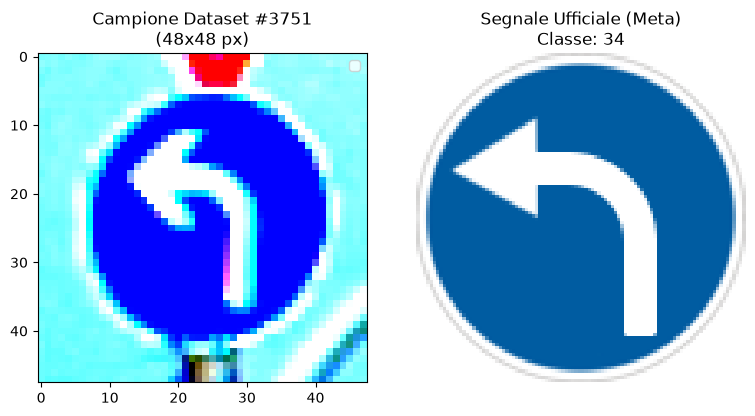

In [14]:
import src.dataset
src.dataset.show_random_sample(ds_test)

#### Inizializziamo e verifichiamo i Dataloaders

#### Metriche
Predisponiamo la funzione per calcolare il set di metriche che descriveranno il comportamento dei modelli sul test set.
* **ACC, Macro Precision (PPV) e Macro Recall (TPR):** Valutano le prestazioni globali distinguendo tra falsi allarmi (bassa precision) e cartelli mancati (bassa recall, critico per la sicurezza stradale); si omettono TNR ed NPV poiché nell'approccio *One-vs-Rest* a 43 classi risulterebbero artificiosamente schiacciate al >99.8%.
* **Macro F1 vs Weighted F1:** Il confronto tra la media non pesata (Macro, che dà pari dignità a tutte le 43 classi) e quella pesata sul supporto isola l'impatto del forte sbilanciamento del dataset sulle classi rare.
* **Top-3 e Top-5 Accuracy:** Misurano la comprensione semantica del modello, verificando se l'etichetta corretta ricade tra le ipotesi più plausibili in caso di ambiguità visiva tra classi della stessa famiglia (es. limiti di velocità o frecce).



In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    top_k_accuracy_score
)
def calculate_metrics(y_true, y_pred, y_probs=None, model_name="Modello"):
    """
    Calcola in modo standardizzato le metriche per la classificazione multiclasse:
    - ACC: Accuracy
    - Macro PPV: Precision media (Positive Predictive Value)
    - Macro TPR: Recall media (True Positive Rate / Sensitivity)
    - Macro F1: Bilanciamento tra Precision e Recall
    - Weighted F1: F1 pesata per il supporto delle classi
    - Top-3 e Top-5 Accuracy (se sono fornite le probabilità)
    """
    metrics = {
        "Modello": model_name,
        "Accuracy (%)": accuracy_score(y_true, y_pred) * 100,
        "Macro Precision / PPV (%)": precision_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "Macro Recall / TPR (%)": recall_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "Macro F1 (%)": f1_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "Weighted F1 (%)": f1_score(y_true, y_pred, average="weighted", zero_division=0) * 100,
        "Top-3 Acc (%)": top_k_accuracy_score(y_true, y_probs, k=3) * 100 if y_probs is not None else None,
        "Top-5 Acc (%)": top_k_accuracy_score(y_true, y_probs, k=5) * 100 if y_probs is not None else None,
    }
    return metrics



In [16]:
import seaborn as sns
def plot_metrics(
    *metrics_args,
    save_plot_path=None
):
    """
    Raccoglie i risultati di N modelli, mostra la tabella comparativa e genera il grafico a barre.
    
    Parametri:
    - *metrics_args: Dizionari di metriche (passati separati o come lista/tupla).
    - save_plot_path: Percorso di salvataggio dell'immagine (None per non salvare).
    
    Ritorna:
    - pd.DataFrame con il confronto ordinato.
    """
    # 1. Normalizziamo gli input per accettare sia func(m1, m2) che func([m1, m2])
    if len(metrics_args) == 1 and isinstance(metrics_args[0], (list, tuple)):
        metrics_list = list(metrics_args[0])
    else:
        metrics_list = list(metrics_args)
        
    if not metrics_list:
        raise ValueError("Fornire almeno un set di metriche da confrontare.")
    # 2. Costruzione del DataFrame riassuntivo
    df_results = pd.DataFrame(metrics_list)
    
    # Arrotondiamo i valori numerici a 2 cifre decimali
    numeric_cols = df_results.select_dtypes(include=[np.number]).columns
    df_results[numeric_cols] = df_results[numeric_cols].round(2)
    
    # Mostriamo la tabella a video
    display(df_results)
    
    df_plot = pd.melt(
        df_results, 
        id_vars=["Modello"], 
        var_name="Metrica", 
        value_name="Punteggio (%)"
    )
    # 5. Generazione del grafico con larghezza dinamica in base al numero di modelli
    n_models = len(df_results)
    plt.figure(figsize=(max(8, n_models * 3.2), 5.5))
    sns.set_theme(style="whitegrid")
    
    ax = sns.barplot(
        data=df_plot, 
        x="Modello", 
        y="Punteggio (%)", 
        hue="Metrica", 
        palette="viridis"
    )
    plt.title("Confronto Prestazioni Modelli sul Test Set (GTSRB)", fontsize=13, fontweight="bold", pad=15)
    plt.xlabel("Architettura / Modello", fontsize=11, labelpad=10)
    plt.ylabel("Punteggio (%)", fontsize=11)
    plt.ylim(0, 105)
    plt.legend(title="Metrica", loc="lower right", frameon=True)
    # Aggiunta etichette percentuali sopra le barre
    for p in ax.patches:
        height = p.get_height()
        if height is not None and not np.isnan(height) and height > 0:
            ax.annotate(
                f"{height:.1f}%",
                (p.get_x() + p.get_width() / 2., height),
                ha="center", va="bottom",
                fontsize=9, xytext=(0, 3),
                textcoords="offset points"
            )
    plt.tight_layout()
    # 6. Salvataggio del grafico
    if save_plot_path:
        os.makedirs(os.path.dirname(save_plot_path), exist_ok=True)
        plt.savefig(save_plot_path, dpi=300)
        print(f"--> Grafico salvato in: '{save_plot_path}'")
        
    plt.show()
    return df_results

In [17]:
batch_size = 128  

train_loader = torch.utils.data.DataLoader(ds_train, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=0)
val_loader   = torch.utils.data.DataLoader(ds_val,   batch_size=batch_size, shuffle=False, pin_memory=True,num_workers=0)
test_loader  = torch.utils.data.DataLoader(ds_test,  batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=0)

print("=== 1. VERIFICA DATALOADER ===")
loaders = {
    "Train": train_loader,
    "Validation": val_loader,
    "Test": test_loader
}
for name, loader in loaders.items():
    # Estraiamo il primo batch reale
    batch = next(iter(loader))
    images, labels = batch["image"], batch["label"]
    
    print(f"\n[{name} Loader]")
    print(f" - Numero totale batch:  {len(loader)}")
    print(f" - Immagini Shape:       {images.shape} (atteso: [BatchSize, 3, 48, 48])")
    print(f" - Immagini Dtype:       {images.dtype} (atteso: torch.float32)")
    print(f" - Range Pixel:          min={images.min():.2f}, max={images.max():.2f} (normalizzato)")
    print(f" - Etichette Shape:      {labels.shape} (atteso: [BatchSize])")
    print(f" - Range Etichette:      min={labels.min().item()}, max={labels.max().item()} (atteso tra 0 e 42)")
    
    # Asserzioni automatiche di sicurezza
    assert images.dim() == 4 and images.shape[1] == 3 and images.shape[2:] == (48, 48), "Errore nelle dimensioni delle immagini!"
    assert labels.min() >= 0 and labels.max() < 43, "Etichette fuori range [0, 42]!"
    assert images.dtype == torch.float32, "Il tipo delle immagini deve essere float32!"

=== 1. VERIFICA DATALOADER ===

[Train Loader]
 - Numero totale batch:  246
 - Immagini Shape:       torch.Size([128, 3, 48, 48]) (atteso: [BatchSize, 3, 48, 48])
 - Immagini Dtype:       torch.float32 (atteso: torch.float32)
 - Range Pixel:          min=-2.05, max=2.64 (normalizzato)
 - Etichette Shape:      torch.Size([128]) (atteso: [BatchSize])
 - Range Etichette:      min=0, max=42 (atteso tra 0 e 42)

[Validation Loader]
 - Numero totale batch:  62
 - Immagini Shape:       torch.Size([128, 3, 48, 48]) (atteso: [BatchSize, 3, 48, 48])
 - Immagini Dtype:       torch.float32 (atteso: torch.float32)
 - Range Pixel:          min=-2.10, max=2.64 (normalizzato)
 - Etichette Shape:      torch.Size([128]) (atteso: [BatchSize])
 - Range Etichette:      min=0, max=41 (atteso tra 0 e 42)

[Test Loader]
 - Numero totale batch:  99
 - Immagini Shape:       torch.Size([128, 3, 48, 48]) (atteso: [BatchSize, 3, 48, 48])
 - Immagini Dtype:       torch.float32 (atteso: torch.float32)
 - Range Pixel

### Modelli di machine learning
Trattandosi di classificazione di immagini, la scelta del primo modello da testare, che diverrà la nostra baseline, ricade d'obbligo su un regressore logistico le cui feature sono le rappresentazioni interne prodotte da ResNet18, come visto in laboratorio.

Scarichiamo il modello e carichiamolo in memoria.

In [18]:
from torchvision import models
from torch import nn
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
# 1. Carichiamo ResNet-18 pre-addestrata su ImageNet (pesi DEFAULT)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--> Dispositivo per estrazione feature: {device}")

weights = models.ResNet18_Weights.DEFAULT
resnet18 = models.resnet18(weights=weights)
resnet18

--> Dispositivo per estrazione feature: cuda


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

Per ottenere il feature extractor rimuoviamo l'ultimo layer, cioè quello fully connected (esattamente come nel LAB).

In [19]:
# children()[:-1] include tutti i layer fino all'AdaptiveAvgPool2d (output shape: [B, 512, 1, 1])
feature_extractor = nn.Sequential(*list(resnet18.children())[:-1]).to(device)
feature_extractor.eval()  # Modalità inferenza (disattiva dropout/batchnorm training)

print("--> Feature Extractor ResNet-18 pronto (Embedding size: 512)")


--> Feature Extractor ResNet-18 pronto (Embedding size: 512)


Definiamo adesso la funzione che ci permetterà di trasformare le nostre immagini in feature.

Estraiamo le feature per training, validation e test set e salviamole aggregate su un file .npz  
Questa operazione va fatta una volta sola e ci permette di allenare tutti i modelli che vogliamo su tali rappresentazioni.
Una volta estratte le feature disattiviamo la cella del notebook per le successive esecuzioni.

In [20]:
# 1. Caricamento delle matrici pre-calcolate
features_path = "../results/gtsrb_resnet18_features.npz"

data = np.load(features_path)
X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val     = data["X_val"], data["y_val"]
X_test, y_test   = data["X_test"], data["y_test"]

print("--> Feature caricate con successo:")
print(f"  • Train: {X_train.shape} campioni", "y_train:", y_train.shape)
print(f"  • Val:   {X_val.shape} campioni", "y_val:", y_val.shape)
print(f"  • Test:  {X_test.shape} campioni", "y_test:", y_test.shape)


--> Feature caricate con successo:
  • Train: (31367, 512) campioni y_train: (31367,)
  • Val:   (7842, 512) campioni y_val: (7842,)
  • Test:  (12630, 512) campioni y_test: (12630,)


In [21]:
print("--> [1/2] Addestramento Logistic Regression su 512-D embeddings...")
t0 = time.time()

# max_iter=1000 per dare tempo all'ottimizzatore lbfgs di convergere su 512 feature
# random_state per riproducibilità
lr_clf = LogisticRegression(max_iter=5000, random_state=42)
lr_clf.fit(X_train, y_train)

train_time_lr = time.time() - t0
print(f"--> Addestramento completato in {train_time_lr:.2f} secondi.")

--> [1/2] Addestramento Logistic Regression su 512-D embeddings...
--> Addestramento completato in 253.32 secondi.


,Modello,Accuracy (%),Macro Precision / PPV (%),Macro Recall / TPR (%),Macro F1 (%),Weighted F1 (%),Top-3 Acc (%),Top-5 Acc (%)
0,ResNet-18 + LR (48x48),60.21,52.08,50.71,51.16,59.96,83.67,92.15


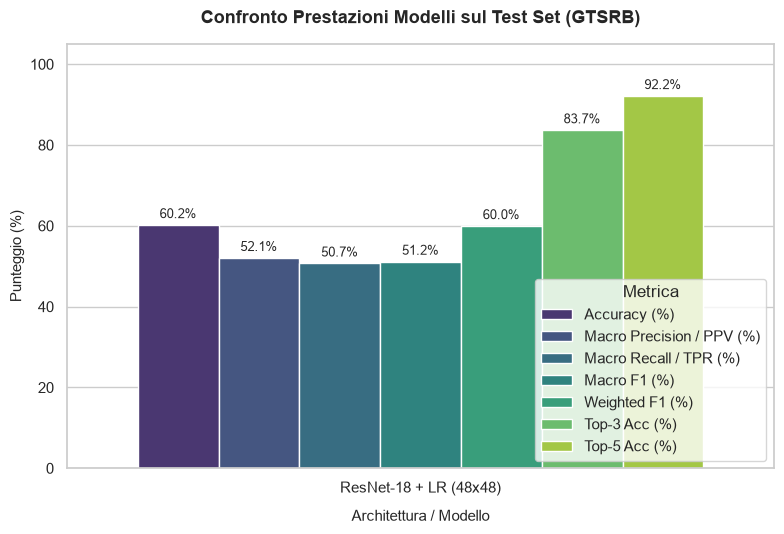

,Modello,Accuracy (%),Macro Precision / PPV (%),Macro Recall / TPR (%),Macro F1 (%),Weighted F1 (%),Top-3 Acc (%),Top-5 Acc (%)
0,ResNet-18 + LR (48x48),60.21,52.08,50.71,51.16,59.96,83.67,92.15


In [22]:
# Valutazione sul Test Set
y_probs_lr = lr_clf.predict_proba(X_test)
y_pred_lr = np.argmax(y_probs_lr, axis=1)


metrics_lr= calculate_metrics(y_test, y_pred_lr, y_probs_lr,"ResNet-18 + LR (48x48)")
plot_metrics(metrics_lr)



#### Bassa accuracy, probabile errore di risoluzione
Possiamo osservare come questo primo modello ottenga una bassa accuracy, potrebbe essere perchè abbiamo scelto arbitrariamente di effettuare il resizing della immagini a 48x48 mentre ResNet-18 è allenata su immagini 224x224.
Riscriviamo quindi le trasformazioni applicate alle immagini affinché la dimensione definitiva sia 224x224.


In [23]:
# Transform specifico per ResNet-18 (standard ImageNet 224x224)
resnet_transforms = v2.Compose([
    v2.Resize((224, 224), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Creiamo dataset e loader dedicati all'estrazione
ds_train_res = CustomGTSRB(img_dir="../data", ann_df=df_train, transform=resnet_transforms)
ds_val_res   = CustomGTSRB(img_dir="../data", ann_df=df_val,   transform=resnet_transforms)
ds_test_res  = CustomGTSRB.from_csv("../data", "Test.csv",     transform=resnet_transforms)

# batch_size a 128 (o 64 se la VRAM della tua GPU è ridotta)
batch_size_res = 128

train_loader_res = torch.utils.data.DataLoader(ds_train_res, batch_size=batch_size_res, shuffle=False, pin_memory=True, num_workers=0)
val_loader_res   = torch.utils.data.DataLoader(ds_val_res,   batch_size=batch_size_res, shuffle=False, pin_memory=True, num_workers=0)
test_loader_res  = torch.utils.data.DataLoader(ds_test_res,  batch_size=batch_size_res, shuffle=False, pin_memory=True, num_workers=0)


Introduciamo anche uno scaler.

In [24]:
from sklearn.preprocessing import StandardScaler

# 1. Caricamento delle feature a 224x224
features_path_224 = "../results/gtsrb_resnet18_features_224x224.npz"
data = np.load(features_path_224)

X_train_224, y_train_224 = data["X_train"], data["y_train"]
X_val_224, y_val_224     = data["X_val"], data["y_val"]
X_test_224, y_test_224   = data["X_test"], data["y_test"]

print(f"--> Feature caricate: Train={X_train_224.shape}, Val={X_val_224.shape}, Test={X_test_224.shape}")

# 2. Standardizzazione delle feature 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_224)
X_val_scaled   = scaler.transform(X_val_224)
X_test_scaled  = scaler.transform(X_test_224)

# 3. Addestramento Logistic Regression 
print("\n--> Addestramento Logistic Regression su feature 224x224...")
t0 = time.time()
lr_clf_224 = LogisticRegression(max_iter=5000, random_state=42)
lr_clf_224.fit(X_train_scaled, y_train_224)
train_time = time.time() - t0

print(f"--> Addestramento completato in {train_time:.2f} secondi.")


--> Feature caricate: Train=(31367, 512), Val=(7842, 512), Test=(12630, 512)

--> Addestramento Logistic Regression su feature 224x224...
--> Addestramento completato in 15.32 secondi.


,Modello,Accuracy (%),Macro Precision / PPV (%),Macro Recall / TPR (%),Macro F1 (%),Weighted F1 (%),Top-3 Acc (%),Top-5 Acc (%)
0,ResNet-18 + LR (224x224),79.99,76.40,73.16,74.10,79.78,93.61,96.77
1,ResNet-18 + LR (48x48),60.21,52.08,50.71,51.16,59.96,83.67,92.15


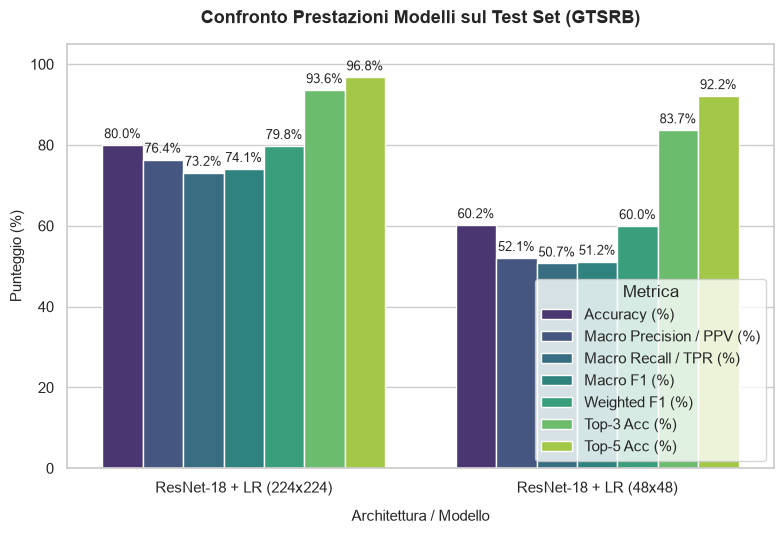

,Modello,Accuracy (%),Macro Precision / PPV (%),Macro Recall / TPR (%),Macro F1 (%),Weighted F1 (%),Top-3 Acc (%),Top-5 Acc (%)
0,ResNet-18 + LR (224x224),79.99,76.40,73.16,74.10,79.78,93.61,96.77
1,ResNet-18 + LR (48x48),60.21,52.08,50.71,51.16,59.96,83.67,92.15


In [25]:
# Valutazione sul Test Set
y_probs_lr_224 = lr_clf_224.predict_proba(X_test_scaled)
y_pred_lr_224 = np.argmax(y_probs_lr_224, axis=1)


metrics_lr_224= calculate_metrics(y_test_224, y_pred_lr_224, y_probs_lr_224,"ResNet-18 + LR (224x224)")
plot_metrics(metrics_lr_224, metrics_lr)


### RandomForest
Sperimentiamo adesso Random Forest, un modello ensamble, che fa uso di bootstrap aggregating.


--> Addestramento Random Forest (100 alberi) su feature 224x224...
--> Addestramento completato in 59.63 secondi.

--> Out-Of-Bag (OOB) Accuracy: 85.24%


,Modello,Accuracy (%),Macro Precision / PPV (%),Macro Recall / TPR (%),Macro F1 (%),Weighted F1 (%),Top-3 Acc (%),Top-5 Acc (%),OOB Acc (%)
0,ResNet-18 + RF (224x224),64.77,64.9,47.90,50.48,62.28,85.23,92.37,85.24
1,ResNet-18 + LR (224x224),79.99,76.4,73.16,74.10,79.78,93.61,96.77,NaN


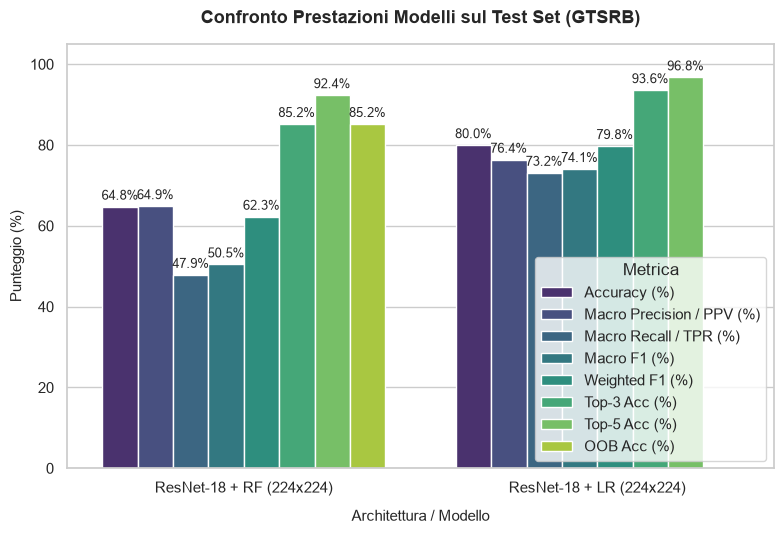

,Modello,Accuracy (%),Macro Precision / PPV (%),Macro Recall / TPR (%),Macro F1 (%),Weighted F1 (%),Top-3 Acc (%),Top-5 Acc (%),OOB Acc (%)
0,ResNet-18 + RF (224x224),64.77,64.9,47.90,50.48,62.28,85.23,92.37,85.24
1,ResNet-18 + LR (224x224),79.99,76.4,73.16,74.10,79.78,93.61,96.77,NaN


In [26]:
from sklearn.ensemble import RandomForestClassifier

print("--> Addestramento Random Forest (100 alberi) su feature 224x224...")
t0 = time.time()

rf_clf_224 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
# Random Forest non risente della scala, possiamo passargli direttamente X_train_224
rf_clf_224.fit(X_train_224, y_train_224)
rf_time = time.time() - t0



print(f"--> Addestramento completato in {rf_time:.2f} secondi.")

oob_acc = rf_clf_224.oob_score_ * 100
print(f"\n--> Out-Of-Bag (OOB) Accuracy: {oob_acc:.2f}%")

y_probs_rf_224 = rf_clf_224.predict_proba(X_test_224)
y_pred_rf_224 = np.argmax(y_probs_rf_224, axis=1)
# 5. Calcolo metriche complete con la nostra funzione
metrics_rf_224 = calculate_metrics(
    y_test_224, 
    y_pred_rf_224, 
    y_probs_rf_224, 
    "ResNet-18 + RF (224x224)"
)
metrics_rf_224["OOB Acc (%)"] = oob_acc

plot_metrics(metrics_rf_224, metrics_lr_224)


#### Analisi intermedia dei risultati
Possiamo osservare che il modello migliore sotto ogni metrica è costituito dall'accoppiata ResNet-18 (come feature extractor) + Logistic Regression a una risoluzione di 224x244.
Possiamo migliorare tale risultato?
Una intuizione potrebbe essere quella di addrestrare una CNN custom da zero. In questa maniera potremmo allenare la CNN a creare delle rappresentazioni migliori per il dominio specifico dei segnali stradali.
Isprirandomi all'esempio di codice del laboratorio, ho deciso di replicare l'architettura MiniAlexNet e di effettuarne il training da zero.


In [27]:
from torch import nn
H=48
W=48
#K è definito sopra
class MiniAlexNet (nn.Module):
    def __init__(self, input_channels=3, out_channels=K):
        super ().__init__()
        self.feature_extractor = nn.Sequential (

            #Conv1
            nn.Conv2d(input_channels, out_channels=16, kernel_size=5, padding= 2), #Input 3 x H x W Output: 16 x H x W
            nn.MaxPool2d(2), #Input 16 x H x W Output 16 x H/2 x W/2
            nn.ReLU(),

            #Conv2
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, padding= 2), #Input 16 x H/2 x W/2 Output: 32 x H/2 x W/2
            nn.MaxPool2d(2), #Input 32 x H/2 x W/2 Output 32 x H/4 x W/4
            nn.ReLU(),

            #Conv3
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), # Input 32 x H/4 x W/4 Output 64 x H/4 X W/4
            nn.ReLU(),

            #Conv4
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1), #Input 64 x H/4 X W/4 Output 128 x H/4 x W/4
            nn.ReLU(),
            
            #Conv5
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1), #Input 128 x H/4 x W/4 Output 256 x H/4 x W/4
            nn.MaxPool2d(2),#Input 256 x H/4 x W/4 Output 256 x H/8 x H/8
            nn.ReLU()
        )
        self.classifier = nn.Sequential (
            #FC6
            nn.Linear(256*(H//8)**2, 2048),
            nn.ReLU(),

            #FC7
            nn.Linear(2048,1024),
            nn.ReLU(),

            #FC8
            nn.Linear(1024, K),
            # Nell'esempio del Prof vi è una RELU alla fine, ma la softmax si aspetta i logits puri
            # quindi l'ho commentata
            #nn.ReLU(),

        )

    def forward(self, x):
        x= self.feature_extractor(x)
        # I layer lineari (nn.Linear) accettano solo matrici 2D del tipo [BatchSize, in_features]
        # x adesso è un tensore 4D [BatchSize, 266, 6, 6]
        # quindi x.shape[0] = BatchSize
        # La funzione .view() in PyTorch serve a cambiare la forma (shape) di un tensore senza spostare o copiare i dati in memoria.
        # Per capirla, immagina la memoria del computer: Tutti i numeri di un tensore sono in realtà memorizzati in RAM come un'unica lunga fila ordinata di numeri (1D).
        #  La funzione .view() non tocca quella fila: cambia solo il "modo" (le "lenti") con cui guardi quella sequenza (ad esempio come una griglia 2D, un cubo 3D o un ipercubo 4D).
        # prende come parametri le nuove dimensioni
        # -1: è un jolly (calcolo automatico). Però si può mettere solo una volta per invocazione.
        # Dice a PyTorch: "Moltiplica tutte le restanti dimensioni tra loro e calcola tu la lunghezza della riga".
        # x= self.classifier (x.view(x.shape[0],-1))
        #view() è rigido: funziona solo se il tensore è contiguo in memoria. Se prima hai fatto un'operazione come .permute() o .transpose(), view() fallisce con un RuntimeError.
        #flatten() è sicuro: se il tensore non è contiguo, se ne occupa lui in automatico (fa una copia contigua internamente) senza mai bloccare l'esecuzione.
        x= self.classifier (x.flatten(1))
        return x
        

##### Attiviamo tensorboard

In [28]:
class AverageValueMeter:
    """
    Accumulatore per calcolare la media esatta (ponderata sul numero di campioni)
    di metriche e loss durante l'epoca. Pattern visto nei LAB 4 e 5.
    """
    def __init__(self):
        self.reset()

    def reset(self):
        self.sum = 0.0
        self.num = 0

    def add(self, value, num):
        self.sum += value * num
        self.num += num

    def value(self):
        try:
            return self.sum / self.num
        except ZeroDivisionError:
            return 0.0


#### Procedura di training
Ho scritto questa funzione di training ispirandomi alla procedura vista in laboratorio.
Come si può notare il validation set viene utilizzato per valutare e conservare il modello migliore tra le varie epoche di training.

In [ ]:
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm

def train_classifier(
    model, 
    train_loader, 
    val_loader, 
    criterion, 
    optimizer, 
    epochs=10, 
    exp_name="unknown_experiment", 
    logdir="logs", 
    device=None
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    print(f"--> Dispositivo di allenamento: {device}")
    model = model.to(device)
    
    # Inizializziamo il SummaryWriter di TensorBoard nella cartella corretta
    writer = SummaryWriter(os.path.join(logdir, exp_name))
    
    # Accumulatori per le metriche
    loss_meter = AverageValueMeter()
    acc_meter = AverageValueMeter()
    
    loaders = {
        "train": train_loader,
        "val": val_loader
    }
    
    best_val_acc = 0.0
    
    for epoch in range(epochs):
        print(f"\n=== Epoca {epoch + 1}/{epochs} ===")
        
        for mode in ["train", "val"]:
            loss_meter.reset()
            acc_meter.reset()
            
            # Pattern PyTorch: attiviamo o disattiviamo dropout/batchnorm e gradienti
            if mode == "train":
                model.train()
            else:
                model.eval()
            
            pbar = tqdm(loaders[mode], desc=f"[{mode.upper()}]", leave=False)
            
            with torch.set_grad_enabled(mode == "train"):
                for batch in pbar:
                    images = batch["image"].to(device)
                    labels = batch["label"].to(device)
                    batch_size = images.size(0)
                    
                    # 1. Forward pass
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    
                    # 2. Backward pass & ottimizzazione (solo in training)
                    if mode == "train":
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()
                    
                    # 3. Calcolo accuratezza
                    preds = outputs.argmax(dim=1)
                    acc = (preds == labels).float().mean().item()
                    
                    # 4. Aggiorniamo i meter ponderati
                    loss_meter.add(loss.item(), batch_size)
                    acc_meter.add(acc, batch_size)
                    
                    # Aggiorniamo la barra tqdm in tempo reale
                    pbar.set_postfix({
                        "loss": f"{loss_meter.value():.4f}", 
                        "acc": f"{acc_meter.value():.4f}"
                    })
            
            epoch_loss = loss_meter.value()
            epoch_acc = acc_meter.value()
            
            print(f"[{mode.upper()}] Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc * 100:.2f}%")
            
            # 5. Logghiamo su TensorBoard alla fine dell'epoca
            writer.add_scalar(f"loss/{mode}", epoch_loss, epoch + 1)
            writer.add_scalar(f"accuracy/{mode}", epoch_acc, epoch + 1)
            
            # Se è la fase di validazione ed è il miglior modello, salviamo i pesi
            if mode == "val" and epoch_acc > best_val_acc:
                best_val_acc = epoch_acc
                os.makedirs("../results/checkpoints", exist_ok=True)
                torch.save(model.state_dict(), f"../results/checkpoints/{exp_name}_best.pth")
                print(f"  --> Salvato nuovo miglior checkpoint (Val Acc: {best_val_acc * 100:.2f}%)")
    
    writer.close()
    print(f"\n--> Training completato! Miglior Val Accuracy: {best_val_acc * 100:.2f}%")
    return model


d:\Desktop\Git\progetto-ml\unict-ml-year-25-nickcacciola\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [30]:
# 1. Istanziamo il modello
model = MiniAlexNet(input_channels=3, out_channels=43)

# 2. Funzione di costo e Ottimizzatore (usiamo Adam con lr 0.001 per partire)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [33]:
trained_model = train_classifier(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=10,
    exp_name="custom_cnn",
    logdir="logs"
)

--> Dispositivo di allenamento: cuda

=== Epoca 1/10 ===


[TRAIN] Loss: 2.4728 - Accuracy: 26.86%


[VAL] Loss: 1.2003 - Accuracy: 58.42%
  --> Salvato nuovo miglior checkpoint (Val Acc: 58.42%)

=== Epoca 2/10 ===


[TRAIN] Loss: 0.4760 - Accuracy: 83.65%


[VAL] Loss: 0.2593 - Accuracy: 91.60%
  --> Salvato nuovo miglior checkpoint (Val Acc: 91.60%)

=== Epoca 3/10 ===


...

[VAL] Loss: 0.0333 - Accuracy: 99.09%
  --> Salvato nuovo miglior checkpoint (Val Acc: 99.09%)

=== Epoca 9/10 ===


[TRAIN] Loss: 0.0228 - Accuracy: 99.41%


[VAL] Loss: 0.0492 - Accuracy: 98.65%

=== Epoca 10/10 ===


[TRAIN] Loss: 0.0197 - Accuracy: 99.43%


[VAL] Loss: 0.0623 - Accuracy: 98.41%

--> Training completato! Miglior Val Accuracy: 99.09%


In [31]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def model_inference(model, test_loader, checkpoint_path, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. Carichiamo i pesi del miglior modello salvato
    print(f"--> Caricamento del miglior checkpoint da: {checkpoint_path}")
    model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
    model.to(device)
    model.eval()  # Disattiva dropout e fissa le statistiche di batchnorm
    
    probs_list = []
    all_preds = []
    all_labels = []
    
    print("--> Valutazione in corso sul Test Set...")
    with torch.no_grad():  # Nessun gradiente, risparmia VRAM e velocizza
        for batch in test_loader:
            images = batch["image"].to(device)
            labels = batch["label"]  # teniamo su CPU per le metriche
            
            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            probs_list.append(probs.cpu())

            preds = logits.argmax(dim=1).cpu()
            
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())
            
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    y_probs_cnn = torch.cat(probs_list, dim=0).numpy()

    return all_labels, all_preds, y_probs_cnn


--> Caricamento del miglior checkpoint da: checkpoints/custom_cnn_best.pth
--> Valutazione in corso sul Test Set...


,Modello,Accuracy (%),Macro Precision / PPV (%),Macro Recall / TPR (%),Macro F1 (%),Weighted F1 (%),Top-3 Acc (%),Top-5 Acc (%)
0,MiniAlexNet,94.69,93.36,91.22,91.8,94.62,98.38,99.01
1,ResNet-18 + LR (224x224),79.99,76.40,73.16,74.1,79.78,93.61,96.77


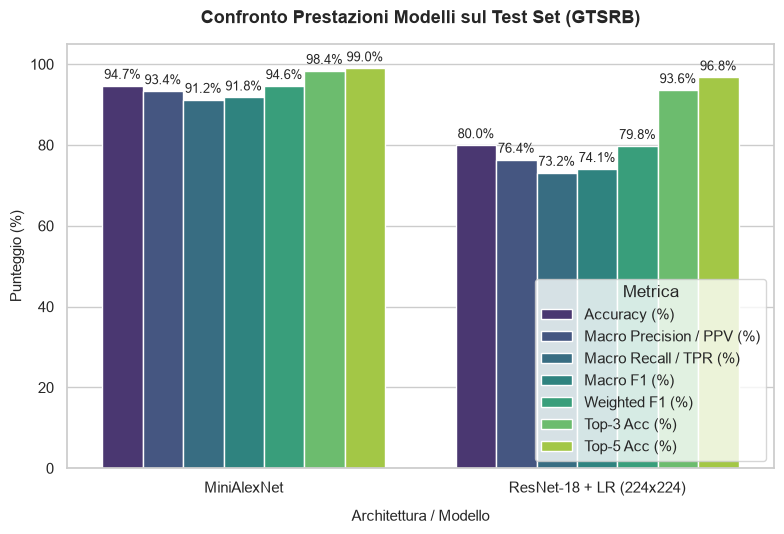

,Modello,Accuracy (%),Macro Precision / PPV (%),Macro Recall / TPR (%),Macro F1 (%),Weighted F1 (%),Top-3 Acc (%),Top-5 Acc (%)
0,MiniAlexNet,94.69,93.36,91.22,91.8,94.62,98.38,99.01
1,ResNet-18 + LR (224x224),79.99,76.40,73.16,74.1,79.78,93.61,96.77


In [34]:
test_labels, test_preds, test_probs = model_inference(
    model=model,
    test_loader=test_loader,
    checkpoint_path="checkpoints/custom_cnn_best.pth"
)
metrics_cnn= calculate_metrics(test_labels, test_preds, test_probs, "MiniAlexNet")
plot_metrics(metrics_cnn, metrics_lr_224)

#### Commento dei risultati ottenuti con MiniAlexNet
Possiamo osservare un boost prestazionale notevole rispetto al nostro precedente miglior modello (ResNet-18 + LR (224x224)).
Un'altra caratteristica degna di nota è lo scarto di quasi tre punti percentuali tra il Weighted F1 ed il Macro F1.
Questo scarto è la dimostrazione matematica dell'impatto del class imbalance che avevamo rilevato nella analisi iniziale: la rete è molto competente sui segnali frequenti (es. limiti di velocità), ma commette più errori sulle classi "di coda" (minoritarie).

Essendo il Macro F1-Score la media aritmetica semplice degli F1-score di tutte le 43 classi, senza pesare sul numero di campioni: $$\text{Macro } F1 = \frac{F1_0 + F1_1 + \dots + F1_{K-1}}{K}$$
Ogni classe ha esattamente lo stesso peso ($1/K$), indipendentemente dal fatto che nel test set abbia 750 immagini o solo 60 immagini!il Macro F1 è la metrica più onesta e severa per giudicare i modelli su questo dataset.

#### Ulteriori visualizzazioni
Sul nostro modello prediletto effettuiamo adesso altre visualizzazioni comuni al mondo della classificazione.
In particolare andremo a visualizzarne la confusion matrix e alcune immagini delle top 4 categorie misclassificate.

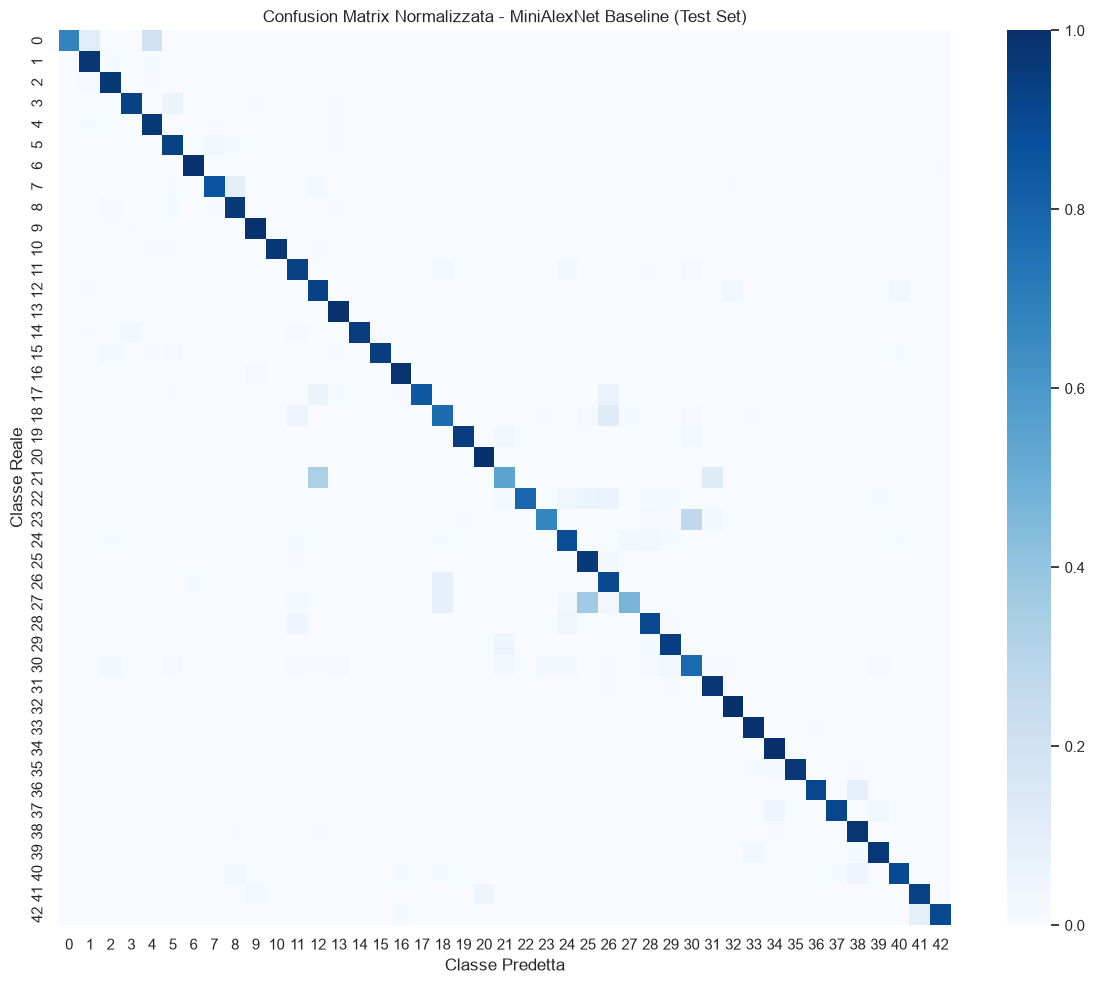

In [ ]:
import seaborn as sns

# Creiamo la cartella media/ se non esiste già
os.makedirs("../media", exist_ok=True)

# Calcolo della Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)


# Grafico della Confusion Matrix Normalizzata
plt.figure(figsize=(12, 10))
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, cmap='Blues', cbar=True)
plt.title("Confusion Matrix Normalizzata - MiniAlexNet (Test Set)")
plt.xlabel("Classe Predetta")
plt.ylabel("Classe Reale")
plt.tight_layout()
plt.savefig("../media/cnn_confusion_matrix.png", dpi=300)
plt.show()



=== LE 4 CATEGORIE PIÙ MISCLASSIFICATE DALLA BASELINE ===
  • Classe 18: 90 errori su 390 campioni (Accuracy di classe: 76.9%)
  • Classe  7: 61 errori su 450 campioni (Accuracy di classe: 86.4%)
  • Classe 17: 56 errori su 360 campioni (Accuracy di classe: 84.4%)
  • Classe 23: 49 errori su 150 campioni (Accuracy di classe: 67.3%)


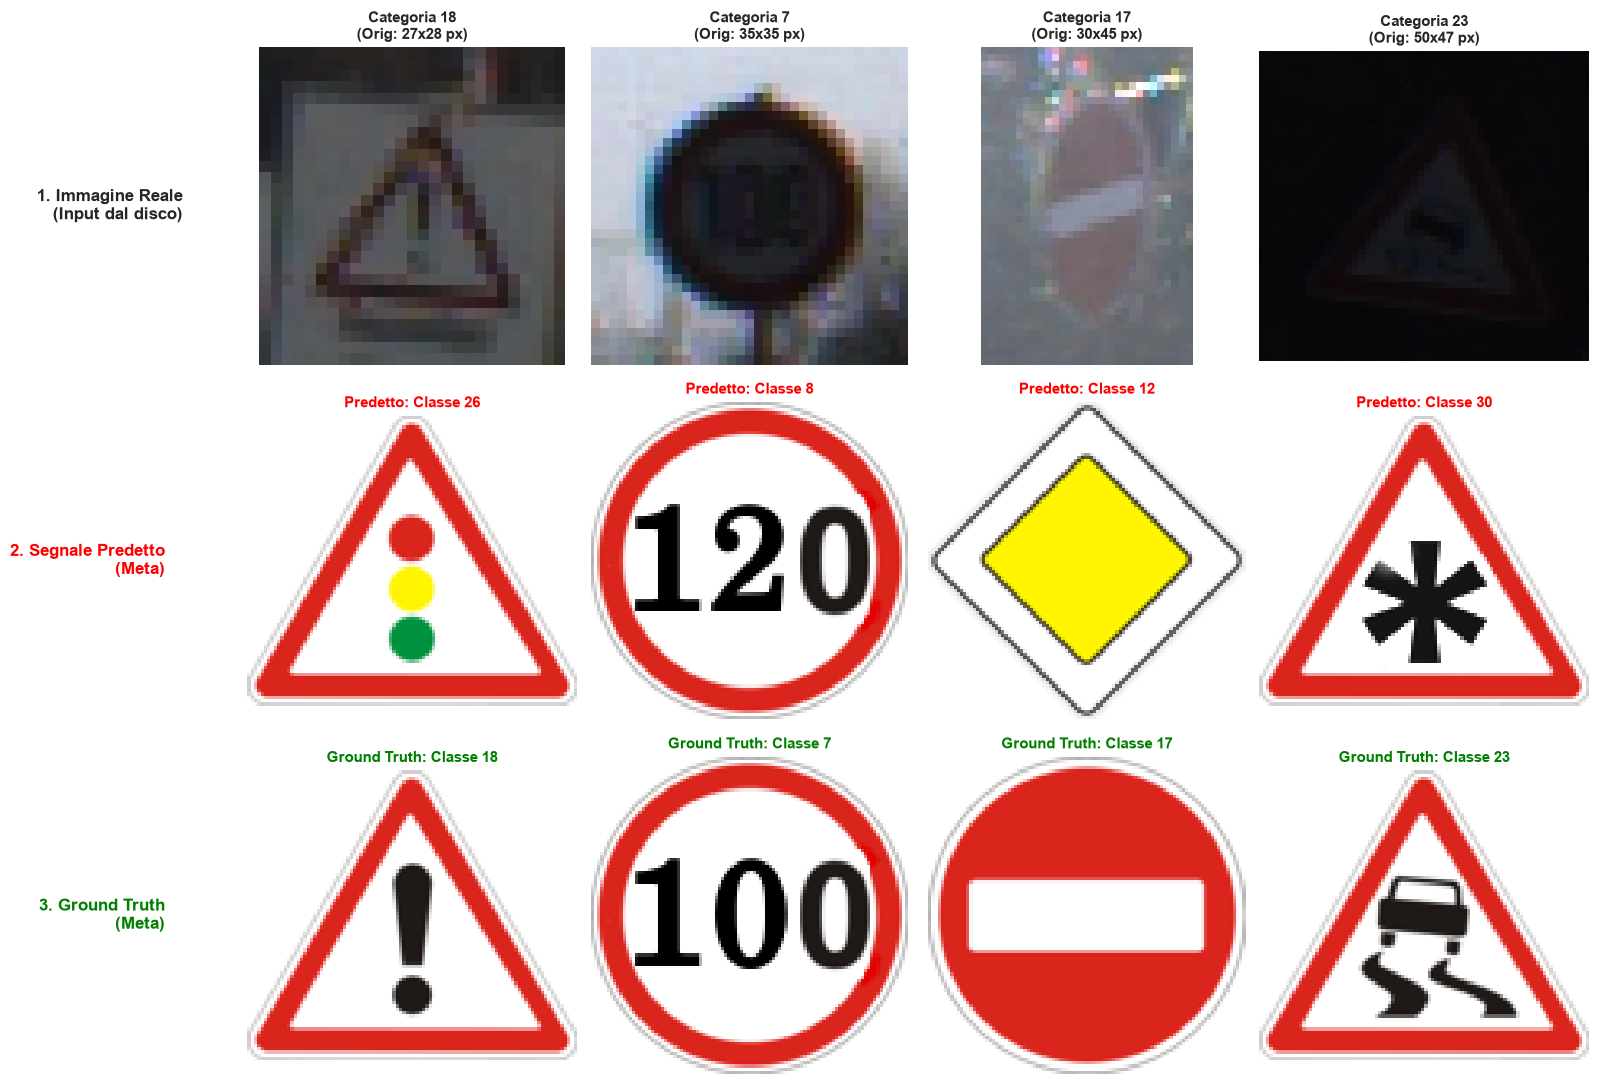

In [ ]:
# 1. Troviamo le 4 categorie (Ground Truth) con il maggior numero di errori nel test set
errors_mask = (test_labels != test_preds)
misclassified_true_labels = test_labels[errors_mask]
top_4_classes = pd.Series(misclassified_true_labels).value_counts().head(4)

print("=== LE 4 CATEGORIE PIÙ MISCLASSIFICATE DA MINIALEXNET ===")
for cls, err_count in top_4_classes.items():
    total_in_class = np.sum(test_labels == cls)
    acc_class = (1 - err_count / total_in_class) * 100
    print(f"  • Classe {cls:2d}: {err_count} errori su {total_in_class} campioni (Accuracy di classe: {acc_class:.1f}%)")

# 2. Creiamo la griglia: 3 righe x 4 colonne
fig, axes = plt.subplots(3, 4, figsize=(16, 11))

for col, cls in enumerate(top_4_classes.index):
    # Indici del test set appartenenti a questa classe ma classificati erroneamente
    class_err_indices = np.where((test_labels == cls) & (test_preds != cls))[0]
    
    # Campionamento CASUALE diverso ad ogni esecuzione
    chosen_idx = np.random.choice(class_err_indices)
    
    true_cls = test_labels[chosen_idx]
    pred_cls = test_preds[chosen_idx]
    row = ds_test.ann_df.iloc[chosen_idx]
    
    # --- RIGA 1: Immagine originale grezza dal disco (senza crop né normalizzazione) ---
    orig_img_path = os.path.join(ds_test.dir, row["Path"])
    orig_img = decode_image(orig_img_path).permute(1, 2, 0).numpy()
    
    # --- RIGA 2: Segnale ufficiale Meta della classe PREDETTA (errore) ---
    meta_pred_path = os.path.join(ds_test.dir, "Meta", f"{pred_cls}.png")
    meta_pred_img = decode_image(meta_pred_path).permute(1, 2, 0).numpy()
    
    # --- RIGA 3: Segnale ufficiale Meta del VERO Ground Truth ---
    meta_true_path = os.path.join(ds_test.dir, "Meta", f"{true_cls}.png")
    meta_true_img = decode_image(meta_true_path).permute(1, 2, 0).numpy()
    
    # Plot Colonna
    axes[0, col].imshow(orig_img)
    axes[0, col].set_title(f"Categoria {true_cls}\n(Orig: {row['Width']}x{row['Height']} px)", fontsize=11, fontweight="bold")
    axes[0, col].axis("off")
    
    axes[1, col].imshow(meta_pred_img)
    axes[1, col].set_title(f"Predetto: Classe {pred_cls}", fontsize=11, color="red", fontweight="bold")
    axes[1, col].axis("off")
    
    axes[2, col].imshow(meta_true_img)
    axes[2, col].set_title(f"Ground Truth: Classe {true_cls}", fontsize=11, color="green", fontweight="bold")
    axes[2, col].axis("off")

# Etichette delle 3 righe sul lato sinistro
axes[0, 0].text(-0.25, 0.5, "1. Immagine Reale\n(Input dal disco)", transform=axes[0, 0].transAxes,
                fontsize=12, fontweight="bold", va="center", ha="right")
axes[1, 0].text(-0.25, 0.5, "2. Segnale Predetto\n(Meta)", transform=axes[1, 0].transAxes,
                fontsize=12, fontweight="bold", va="center", ha="right", color="red")
axes[2, 0].text(-0.25, 0.5, "3. Ground Truth\n(Meta)", transform=axes[2, 0].transAxes,
                fontsize=12, fontweight="bold", va="center", ha="right", color="green")

plt.tight_layout()
plt.show()
